# Statistics Pilot: Test Scores

This notebook renders a simple vertical bar chart. Edit the data and re-run.


In [ ]:
# Bar chart: "Test Scores"
# Works in JupyterLite (Pyodide) or standard Jupyter with matplotlib
import matplotlib.pyplot as plt

labels = ["14-20", "21-25", "25+"]
values = [6, 5, 2]

plt.figure()
plt.bar(labels, values)
plt.title("Test Scores")
plt.xlabel("Score Range")
plt.ylabel("Frequency")
plt.show()

In [1]:
import pandas as pd
df = pd.read_csv("data/scores_cohorts.csv")
df.head()

,cohort,score
0,11th,25
1,11th,20
2,11th,15
3,11th,24
4,11th,14


In [11]:
len(df)

21

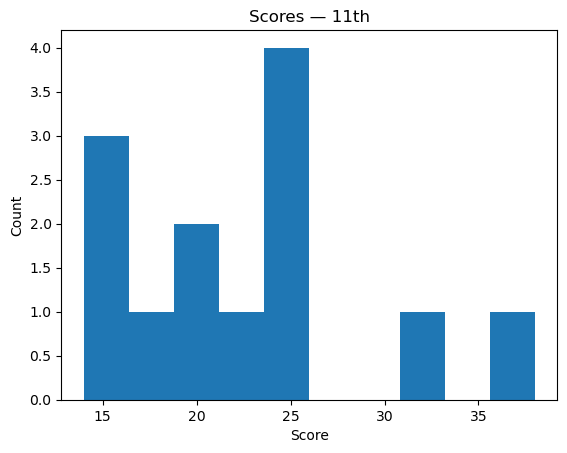

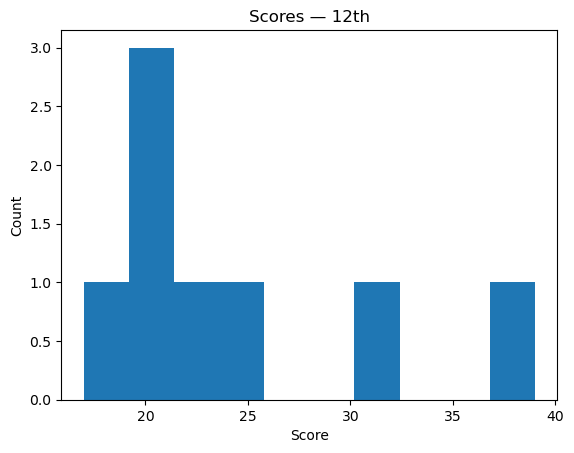

<Figure size 640x480 with 0 Axes>

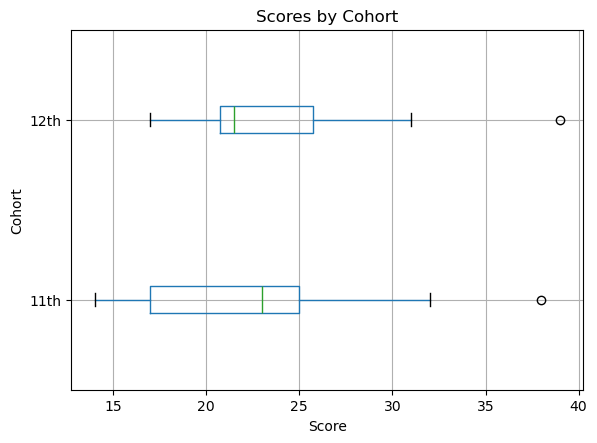

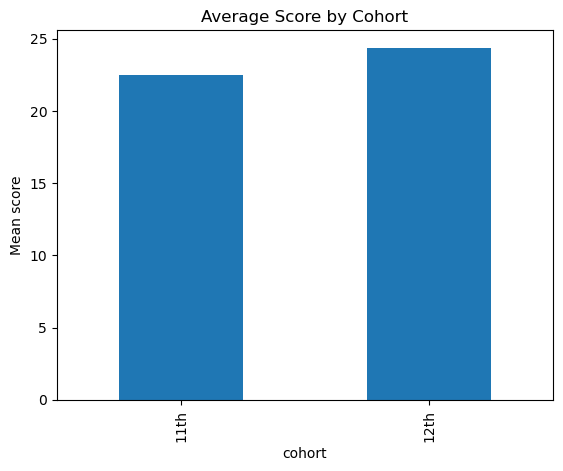

In [3]:
import matplotlib.pyplot as plt

# Histogram by cohort
for grp, sub in df.groupby('cohort'):
    plt.figure()
    plt.hist(sub['score'])
    plt.title(f"Scores — {grp}")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()

# Boxplot by cohort
plt.figure()
df.boxplot(column='score', by='cohort', vert=False)
plt.suptitle("")
plt.title("Scores by Cohort")
plt.xlabel("Score")
plt.ylabel("Cohort")
plt.show()

# Mean bar chart by cohort
plt.figure()
df.groupby('cohort')['score'].mean().plot(kind='bar')
plt.title("Average Score by Cohort")
plt.ylabel("Mean score")
plt.show()

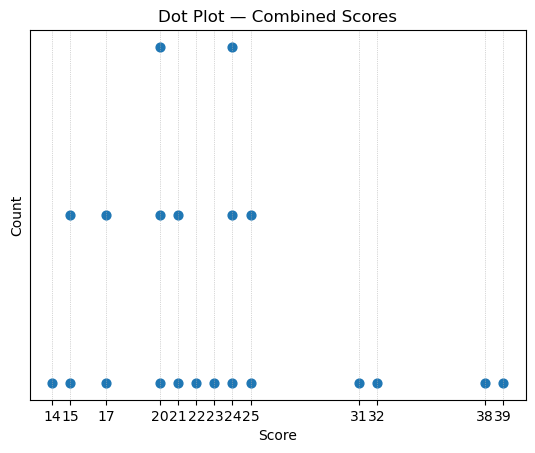

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load from repo-bundled data (notebook is in content/)
df = pd.read_csv("data/scores_cohorts.csv")
scores = df["score"].astype(int)

# Build a stacked dot plot: one dot per student, stacked by score value
counts = scores.value_counts().sort_index()

x = np.concatenate([[val] * cnt for val, cnt in counts.items()])
y = np.concatenate([np.arange(1, cnt + 1) for cnt in counts.values])

plt.figure()
plt.scatter(x, y, s=40)
plt.title("Dot Plot — Combined Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(list(counts.index))   # integer tick for each observed score
plt.yticks([])                   # hide y tick labels (count is encoded by stack height)
plt.grid(axis="x", linestyle=":", linewidth=0.5)
plt.show()

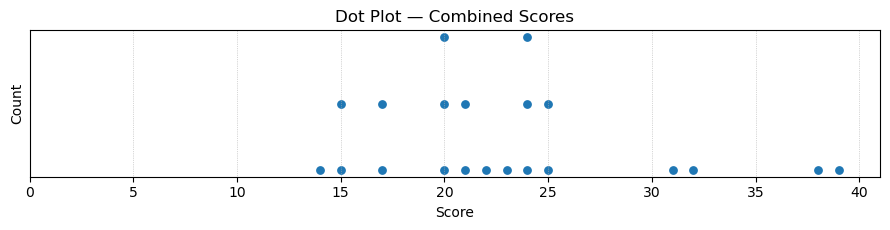

In [8]:

plt.figure(figsize=(9, 2.4))  # short vertical height
plt.scatter(x, y, s=28)
plt.title("Dot Plot — Combined Scores")
plt.xlabel("Score")
plt.ylabel("Count")              # no y label
plt.yticks([])              # hide y ticks
plt.xlim(0, 41)
plt.xticks(np.arange(0, 42, 5))
plt.grid(axis="x", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

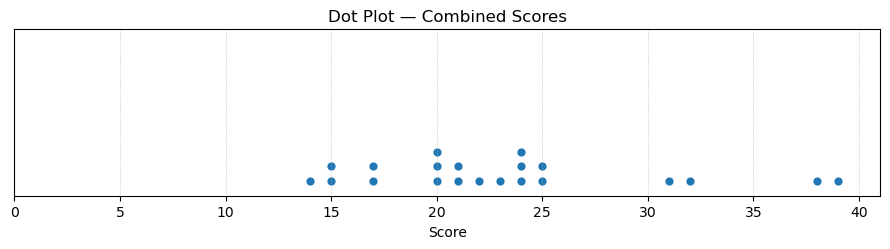

In [10]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv("data/scores_cohorts.csv")
scores = df["score"].astype(int)
counts = scores.value_counts().sort_index()

spacing = 0.12                      # tighter stacking (smaller = tighter)
headroom = 1.0                      # extra space above the tallest stack (in y units)

x = np.concatenate([[v]*c for v,c in counts.items()])
y = np.concatenate([np.arange(c)*spacing + spacing for c in counts.values])

fig, ax = plt.subplots(figsize=(9, 2.6))   # short vertical figure
ax.scatter(x, y, s=24)
ax.set_title("Dot Plot — Combined Scores")
ax.set_xlabel("Score")
ax.set_yticks([])
ax.set_xlim(0, 41)
ax.set_ylim(0, counts.max()*spacing + headroom)  # manual y scale + extra space
ax.margins(y=0)                                  # disable auto top/bottom padding
ax.grid(axis="x", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

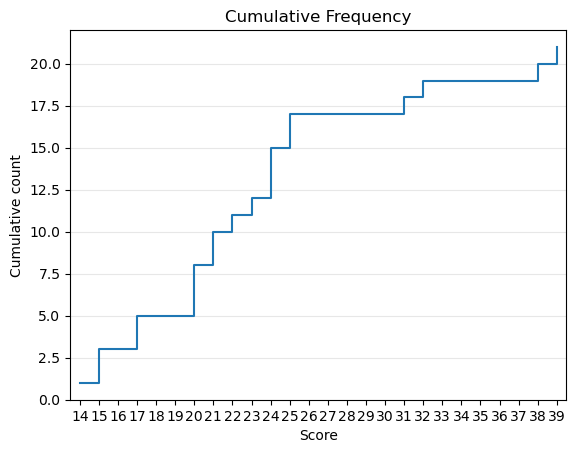

In [12]:
# Cumulative frequency chart (ECDF) aligned to integer score ticks
import numpy as np
import matplotlib.pyplot as plt

# Use df['score'] if present; otherwise fallback to a list/array named `values`
if 'df' in globals() and 'score' in getattr(df, 'columns', []):
    data = df['score'].to_numpy()
elif 'values' in globals():
    data = np.asarray(values)
else:
    raise NameError("Provide data as df['score'] or a list/array named `values`.")

data = np.asarray(data, dtype=float)
xs = np.sort(data)
cum_counts = np.arange(1, xs.size + 1)

# Integer tick marks to match a dot plot of raw scores
xmin, xmax = np.floor(xs.min()), np.ceil(xs.max())

plt.figure()
plt.step(xs, cum_counts, where='post')
plt.xlim(xmin - 0.5, xmax + 0.5)
plt.xticks(np.arange(xmin, xmax + 1, 1))
plt.xlabel("Score")
plt.ylabel("Cumulative count")
plt.title("Cumulative Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Optional: cumulative relative frequency (percent)
# plt.figure()
# plt.step(xs, 100 * cum_counts / len(xs), where='post')
# plt.xlim(xmin - 0.5, xmax + 0.5)
# plt.xticks(np.arange(xmin, xmax + 1, 1))
# plt.xlabel("Score")
# plt.ylabel("Cumulative percent")
# plt.title("Cumulative Relative Frequency")
# plt.grid(axis='y', alpha=0.3)
# plt.show()